# Clustering de Amenazas

Este notebook forma parte de la fase inicial de análisis para el proyecto **Intelligent Antivirus**. En el contexto de computación de alto desempeño, exploramos la agrupación de comportamientos maliciosos utilizando técnicas de clustering, integrando paralelismo de datos para el preprocesamiento masivo y analizando métricas de rendimiento (Speedup y Eficiencia).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import json
from datetime import datetime
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import joblib
from joblib import Parallel, delayed

# Configuración de visualización
%matplotlib inline
plt.style.use('ggplot')

# Crear directorios para reportes si no existen
os.makedirs('../reports', exist_ok=True)

print("Entorno de experimentación HPC listo.")

Entorno de experimentación HPC listo.


## Análisis de Rendimiento HPC

Para validar la aceleración de este pipeline, aplicamos los conceptos de la **Ley de Amdahl**:
1. **Speedup ($S$):** $S = T_s / T_p$, donde $T_s$ es el tiempo secuencial y $T_p$ el paralelo.
2. **Eficiencia ($E$):** $E = S / N$, donde $N$ es el número de núcleos/hilos utilizados.

**Nota sobre el Global Interpreter Lock (GIL):** Usamos `joblib` con el backend de procesos para evitar que el GIL de Python limite el paralelismo en tareas de cómputo intensivo (CPU-bound).

In [2]:
DATA_PATH = '../data/raw/Obfuscated-MalMem2022.csv'
df = pd.read_csv(DATA_PATH)

# Limpieza inicial
df['Category'] = df['Category'].str.split('-').str[:2].str.join('-')
df.drop_duplicates(keep='first', inplace=True)
df['Class'] = df['Class'].map({'Benign': 0, 'Malware': 1})

# Remover columnas con varianza cero (constantes) que no aportan información
zero_var_cols = [col for col in df.columns if df[col].nunique() <= 1]
df.drop(columns=zero_var_cols, inplace=True)

print(f"Dataset cargado. Dimensiones originales: {df.shape}")

Dataset cargado. Dimensiones originales: (58047, 54)


In [54]:
# Selección de columnas numéricas para el preprocesamiento
FEATURE_COLS = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Class' in FEATURE_COLS: FEATURE_COLS.remove('Class')

# Cálculo de estadísticas globales para asegurar corrección matemática en el paralelismo
means = df[FEATURE_COLS].mean()
stds = df[FEATURE_COLS].std() + 1e-8

def parallel_scaler(chunk, global_mean, global_std):
    """
    Función de transformación paralelizable. 
    Simulamos carga pesada repitiendo la operación.
    """
    X = chunk[FEATURE_COLS].copy()
    # Simulación de cómputo intensivo
    for _ in range(10):
        X = (X - global_mean) / global_std
    return X

# 1. Ejecución Secuencial (Baseline)
print("Iniciando ejecución secuencial...")
start_seq = time.time()
X_seq = parallel_scaler(df, means, stds)
t_seq = time.time() - start_seq
print(f"[SECUENCIAL] Tiempo total: {t_seq:.4f}s")

# 2. Ejecución Paralela (HPC)
NUM_WORKERS = joblib.cpu_count()
chunks = np.array_split(df, NUM_WORKERS)
print(f"Iniciando ejecución paralela con {NUM_WORKERS} núcleos...")

start_par = time.time()
# Paralelismo de datos usando Joblib (multiprocessing backend)
results = Parallel(n_jobs=NUM_WORKERS)(
    delayed(parallel_scaler)(chunk, means, stds) for chunk in chunks
)
t_par = time.time() - start_par
X_par = np.vstack(results)

print(f"[PARALELO] Tiempo total: {t_par:.4f}s")

# 3. Métricas de Rendimiento
speedup = t_seq / t_par
efficiency = speedup / NUM_WORKERS

print(f"\n Resultados HPC:")
print(f"- Speedup: {speedup:.2f}x")
print(f"- Eficiencia: {efficiency:.2f}")

Iniciando ejecución secuencial...
[SECUENCIAL] Tiempo total: 0.3290s
Iniciando ejecución paralela con 14 núcleos...


c:\Users\sergiomarin\AppData\Local\anaconda3\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


[PARALELO] Tiempo total: 0.2831s

 Resultados HPC:
- Speedup: 1.16x
- Eficiencia: 0.08


## Clustering y Reducción de Dimensionalidad

Utilizamos PCA para proyectar los datos de alta dimensión en un espacio 2D y evaluar visualmente si el algoritmo K-Means es capaz de reconstruir las agrupaciones naturales de malware frente a las muestras benignas.

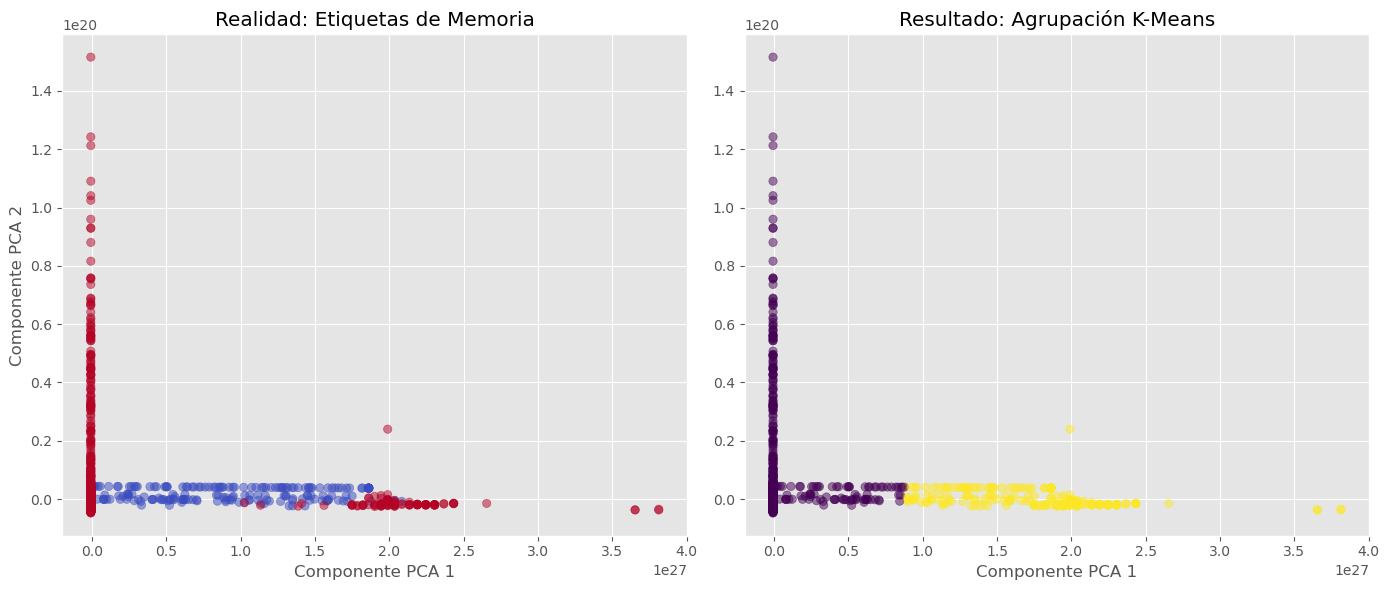

Reporte HPC guardado en ../reports/hpc_metrics.json


In [55]:
# Aplicar PCA para visualización
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_par)

# Clustering K-Means
kmeans = KMeans(n_clusters=2, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_pca)

# Visualización comparativa
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Class'], cmap='coolwarm', alpha=0.5)
plt.title('Realidad: Etiquetas de Memoria')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')

plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5)
plt.title('Resultado: Agrupación K-Means')
plt.xlabel('Componente PCA 1')

plt.tight_layout()
plt.savefig('../reports/hpc_clustering_viz.png')
plt.show()

# Exportación de metadatos para el pipeline CI/CD
report = {
    "experiment": "Clustering_HPC_Memory",
    "timestamp": datetime.now().isoformat(),
    "hpc_metrics": {
        "sequential_time": t_seq,
        "parallel_time": t_par,
        "speedup": speedup,
        "efficiency": efficiency,
        "cores_used": NUM_WORKERS
    }
}

with open('../reports/hpc_metrics.json', 'w') as f:
    json.dump(report, f, indent=4)

print("Reporte HPC guardado en ../reports/hpc_metrics.json")